Only the scalar field timing residual part is "original".. the rest is a combination of tutorial 2 and 3

call it Tutorial 02 and Tutorial 03

just give the website link of epta.. but in the read me 


use efficiency control!


The code takes approximately 4 days now if fully run... improve!

### Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import corner
# enterprise 
from enterprise.pulsar import Pulsar
from enterprise.signals.utils import powerlaw 
from enterprise.signals import white_signals, gp_signals, parameter
from enterprise.signals.signal_base import PTA
from enterprise_extensions.sampler import JumpProposal
from enterprise.signals import selections
from enterprise.signals.selections import Selection
# PTMCMCSampler
from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc

/home/llaett/projects/thesis/master-thesis-code/.venv/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename
PINT not installed. PINT or libstempo are required to use par and tim files.


Optional mpi4py package is not installed.  MPI support is not available.


### Efficiency Control

A single run takes quite some time.  
Reduce these parameters to increase speed (by decreasing accuracy).

In [2]:
#MCMC samples, full run: ~5e5
nsamples = int(5e4)
#Number of considered pulsars, full run: 25
npulsars = 3
#number of Fourier-modes for rednoise, full run: 30
ncomponents=30

### Import the Pulsars

Pulsars are imported and packed into the Enterprise object psrs

In [3]:
psrnames_all = ["J0030+0451", "J0613-0200", "J0751+1807", "J0900-3144", "J1012+5307", 
                "J1022+1001", "J1024-0719", "J1455-3330", "J1600-3053", "J1640+2224", 
                "J1713+0747", "J1730-2304", "J1738+0333", "J1744-1134", "J1751-2857", 
                "J1801-1417", "J1804-2717", "J1843-1113", "J1857+0943", "J1909-3744", 
                "J1910+1256", "J1911+1347", "J1918-0642", "J2124-3358", "J2322+2057"]
psrnames = psrnames_all[:npulsars]
parfiles = [f"../data/DR2new/{p}/{p}.par" for p in psrnames]      #timing model parameters
timfiles = [f"../data/DR2new/{p}/{p}_all.tim" for p in psrnames]  #timefiles

In [4]:
devnull = os.open(os.devnull, os.O_WRONLY)     #these lines are only to avoid 
old_stdout, old_stderr = os.dup(1), os.dup(2)  #debug outputs of Pulsar fct
os.dup2(devnull, 1)                            #
os.dup2(devnull, 2)                            #

psrs = [Pulsar(par, tim, ephem='DE440') for par, tim in zip(parfiles, timfiles)]

os.dup2(old_stdout, 1)     #these lines are only to avoid
os.dup2(old_stderr, 2)     #debug outputs of Pulsar fct
os.close(devnull)          #
os.close(old_stdout)       #
os.close(old_stderr)       #
#print(len(psrs))

### Priors

Define the priors according to the Thesis.

In [5]:
#white noise
efac_prior = parameter.Uniform(0, 10)
log10_equad_prior = parameter.Uniform(-10, -5)
#rednoise
log10_A_rn_prior = parameter.Uniform(-20, -6)
gamma_rn_prior = parameter.Uniform(0, 10)
#CURN, pulsar independent
log10_A_curn_prior = parameter.Uniform(-20, -6)("Curn")
#scalar field parameters, pulsar independent
log10_Psi_X_prior = parameter.Uniform(-20, -12)("log10_Psi")
log10_m_prior     = parameter.Uniform(-24, -22)("log10_m")
deltaE_prior      = parameter.Uniform(0, 2)("deltaE")
gammaE_prior      = parameter.Uniform(0, 2*np.pi)("gammaE")
#scalar field parameters, pulsar dependent
deltaP_prior = parameter.Uniform(0, 2)
gammaP_prior = parameter.Uniform(0, 2*np.pi)

## Create Timing Model
The Timing Model is included as a Guassian Process. We will marginalized over its parameters.

In [6]:
s = gp_signals.TimingModel()

In [7]:
selection = Selection(selections.by_backend)  #used if multiple pulsars are considered

### Add white noise

In [8]:
s += white_signals.MeasurementNoise(
    efac=efac_prior,
    log10_t2equad=log10_equad_prior,
    selection=selection
)

### Add red noise

In [9]:
pl = powerlaw(log10_A=log10_A_rn_prior, gamma=gamma_rn_prior)

s += gp_signals.FourierBasisGP(
    pl,
    components=ncomponents,
    selection=selection
)

### Add common uncorrelated red noise (CURN)

In [10]:
pl_curn = powerlaw(log10_A=log10_A_curn_prior, gamma=13/3)  

s += gp_signals.FourierBasisGP(
    pl_curn,
    components=ncomponents,
    name='curn'
)

### Add dispersion measure variations (DMV)

Tutorial 02 includes DMV.  
The sixth paper of EPTA DR2 which is discussed in the Thesis absorbed DMV in white and red noise. As the goal of this code is to reproduce their results we will do the same. 

### Add Scalar Field DM induced timing residual

In [11]:
from enterprise.signals import deterministic_signals, signal_base

@signal_base.function
def R_m(toas, lgPsi, lgm, dE, dP, gE, gP):
    Psi = 10**lgPsi
    m_eV = 10**lgm
    omega = 2 * m_eV * 1.5192674e15  #2m in rad/s
    t = toas - toas.min()   #sec, shifted
    #measurable timing residual
    Rm = (Psi / omega) * (dE*np.sin(omega*t+gE) + dP*np.sin(omega*t+gP))
    return Rm

sfdm = deterministic_signals.Deterministic(
    R_m(
        lgPsi=log10_Psi_X_prior,
        lgm=log10_m_prior,
        dE=deltaE_prior,
        dP=deltaP_prior,
        gE=gammaE_prior,
        gP=gammaP_prior,
    ),
    name="sfdm"
)

s += sfdm

## Create PTA object

Create PTA object for the model above.

In [12]:
pta = PTA([s(psr) for psr in psrs])

## Sampling 

In [13]:
# output directory 
outdir = "./../chains"
os.makedirs(outdir, exist_ok=True) #create if not there yet

# Write parameter names
with open(os.path.join(outdir, "pars.txt"), "w") as fout:
    for pname in pta.param_names:
        fout.write(pname + "\n")

# Initial sample
x0 = np.hstack([p.sample() for p in pta.params])

# Number of parameters
ndim = len(x0)

# Initial covariance
cov = np.diag(np.ones(ndim) * 0.05**2) #they use 0.01 in the Tutorial but the acceptance non-ideal there

# Sampler
sampler = ptmcmc(ndim, pta.get_lnlikelihood, pta.get_lnprior, cov, outDir=outdir)

### Set the jump proposals

The jump proposals in Tutorial 02 results in an error due to the draw_from_par_prior function.  
Here we use an adjusted function called make_prior_jump to avoid this error.   
I assume that there exist better jump proposals which would increase the accuracy without decreasing efficiency, but I did not find any. 

In [14]:
def make_prior_jump(pta, par_match):
    par_list = [p for p in pta.params if par_match in str(p)]
    pmap = {str(p): i for i, p in enumerate(pta.params)}

    def draw(x, iter, beta):
        q = x.copy()

        # choose one matching parameter
        param = np.random.choice(par_list)
        idx = pmap[str(param)]

        old = np.atleast_1d(q[idx]).copy()
        new = np.atleast_1d(param.sample()).copy()

        q[idx] = new[0] if len(new) == 1 else new

        lqxy = np.sum(param.get_logpdf(old)) - np.sum(param.get_logpdf(new))
        return q, float(lqxy)

    return draw

In [15]:
# custom jump proposals
jump_groups = {
    "log10_Psi": 20,
    "log10_m": 20,
    "gammaE": 10,
    "deltaE": 10,
    "sfdm": 20,
    "red_noise": 10,
    "measurement_noise": 10,
    "curn": 10,
}

for name, weight in jump_groups.items():
    if any(name in str(p) for p in pta.params):
        sampler.addProposalToCycle(make_prior_jump(pta, name), weight)

### Sample parameters

In [16]:
sampler.sample(x0, int(nsamples), SCAMweight=20, DEweight=60, AMweight=20, isave=200)

#Scamweight = 40 is used in tutorial but this yields in high acceptance

Finished 0.40 percent in 4.502436 s Acceptance rate = 0.78

/home/llaett/projects/thesis/master-thesis-code/.venv/lib/python3.12/site-packages/enterprise/signals/parameter.py:70: RuntimeWarning: divide by zero encountered in log
  logpdf = np.log(self.prior(value, **kwargs))


Finished 20.00 percent in 172.434888 s Acceptance rate = 0.298Adding DE jump with weight 60
Finished 100.00 percent in 689.768297 s Acceptance rate = 0.45892
Run Complete


## Analyse chain 

This part is only needed for code improvement.  
Idealy the Chains are diffuse and the corner plots provide nice gaussian-like peaks.

In [17]:
# Load chain file
ch = np.loadtxt("%s/chain_1.txt"%outdir)

# Remove the burnin
ch = ch[int(len(ch)*.5):]
pars = np.loadtxt("%s/pars.txt"%outdir, dtype=str)

In [18]:
# find indices
i_psi = list(pars).index("log10_Psi")
i_m   = list(pars).index("log10_m")
i_gammaE = list(pars).index("gammaE")
i_deltaE = list(pars).index("deltaE")
i_curn = list(pars).index("Curn")

inds = [i_psi, i_m, i_gammaE, i_deltaE, i_curn]
inds_label = ["log10_Psi", "log10_m", "gammaE", "deltaE", "Curn"]

### Plot chain

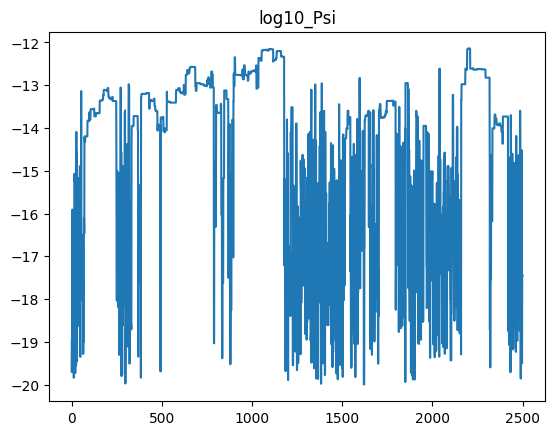

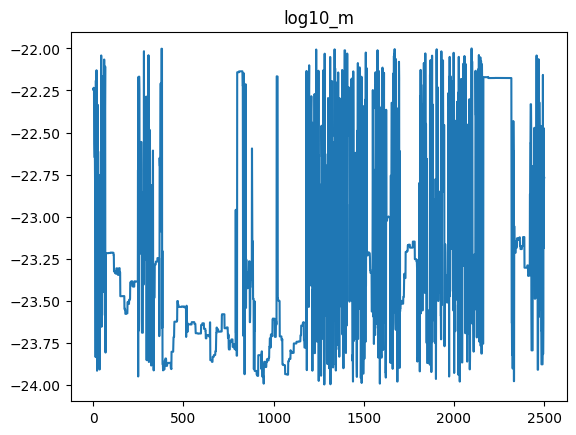

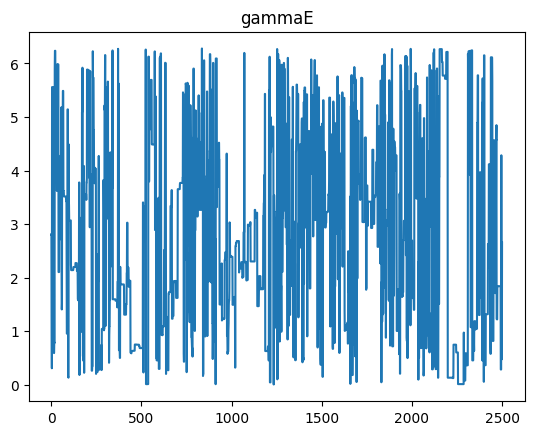

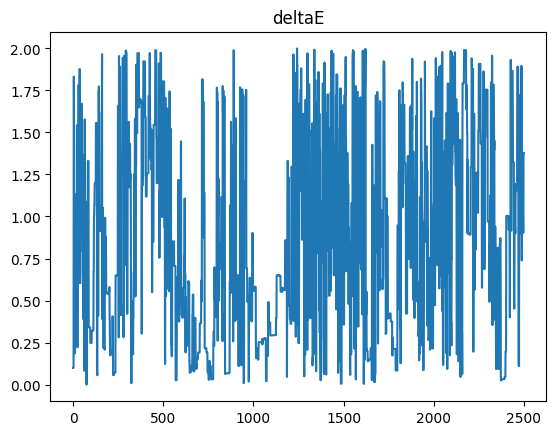

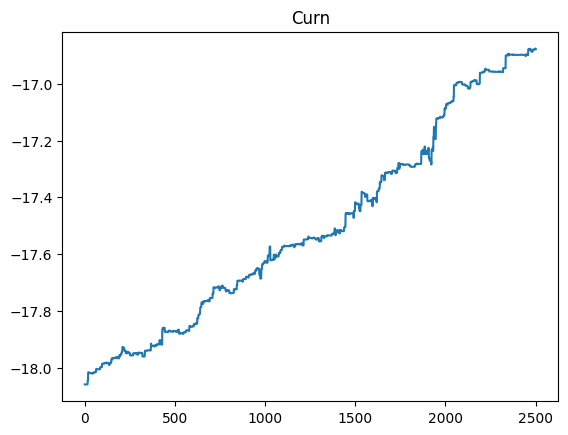

In [19]:
for i in inds:
    plt.title(pars[i])
    plt.plot(ch[:, i])
    plt.show()

### Plot Corner plots

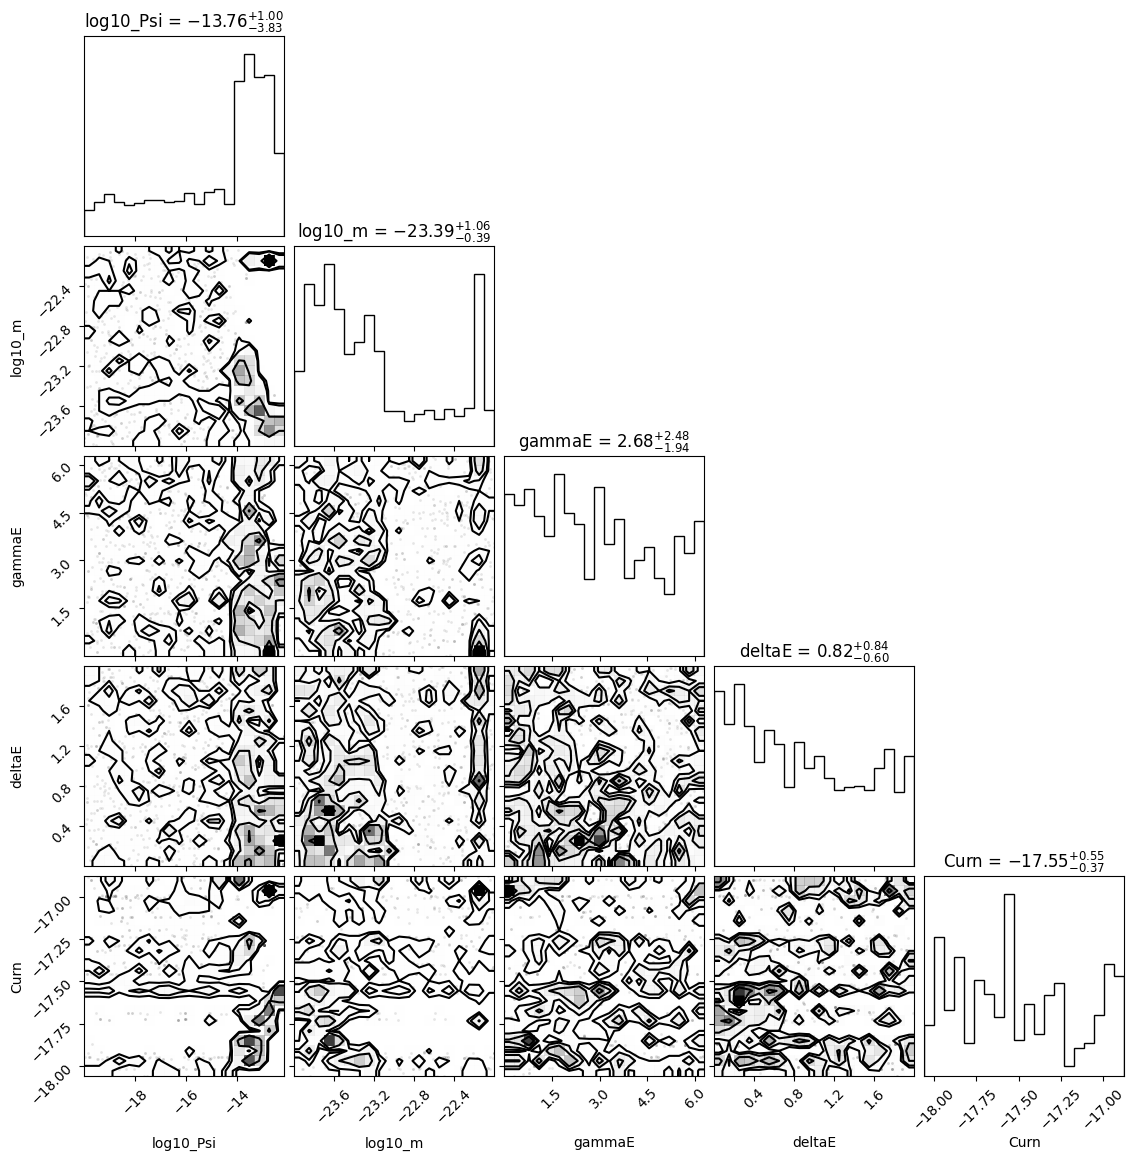

In [20]:
ch_sub = ch[:, inds]  #only the global param
figure = corner.corner(ch_sub, labels=inds_label, show_titles=True)
plt.show()

### Plot Psi vs m

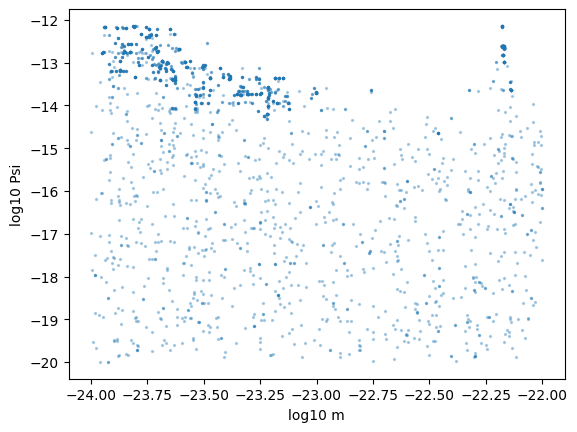

In [21]:
plt.scatter(ch[:, i_m], ch[:, i_psi], s=2, alpha=0.3)
plt.xlabel("log10 m")
plt.ylabel("log10 Psi")
plt.show()